# Treat PbP data
This is the GFAS PbP treatment routine. It will produce (and save if turned on) binned and aggregated datasets in a 1Hz time resolution. Note that every single day has to be read in separately and it might take some mintues.

It uses the following datasets: 
- raw PbP observational data
- raw 1Hz data for sample flow
- scale factors in PbP_processing/detector_scaling_factors

Sub-routines needed:
- PbP_processing/GFAS101_processing
- GFAS_reading/GFAS101_read_in
- PbP_processing/loss_Calc_functions_GFAS101

Correction/Treatment applied
- attenuation
- scaling towards theoretical values
- sizing
- losses
- binning of 
    - polarization data, 
    - size distribution data, 
    - number concentration, 
    - effective diameter, 
    - and liquid water content

Output
- polarization dataframe 1 hz
- F/B dataframe 1 Hz
- N, Deff, LWC, dN/dlogDp 1Hz dataframe 
- N, Deff, LWC, dN/dlogDp 1Hz dataframe loss-corrected 



author: Lea Haberstock, Stockholm University, Department of Environmental Science, Atmospheric Unit \
developed toether with: Darrel Baumgardner and Paul Zieger

contact: lea.haberstock@aces.su.se \
used in publication: Haberstock et al. 2026 (submitted to AMT) 






In [ ]:
import sys  
import numpy as np
import pandas as pd
#import glob2
import glob, os
import os
from io import BytesIO
import datetime as dt
import calendar
from pandas.errors import EmptyDataError
from scipy.ndimage import shift
import scipy

from matplotlib.pyplot import figure
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as colors
import seaborn as sns 
#import PyMieScatt as ps
import matplotlib.ticker as ticker
import matplotlib 
from zipfile import ZipFile
import dask
import dask.dataframe as dd
import importlib

importlib.reload(lc)
from pathlib import Path

project_dir = Path.cwd().parent
sys.path.append(str(project_dir))
from GFAS101_processing import *
from GFAS_reading.GFAS101_read_in import *

import loss_Calc_functions_GFAS101 as lc

## read in and treatment functions

In [120]:
# read in GFAS PbP data
# correction factor for attenuation of the laser signal, based on the FWHM of the peaks in the size distribution
def CF(fwhm):
    CF = 1 + 0.00404079 * fwhm**1.07336
    return CF

# apply correction factor to the peaks in the size distribution
def attenuation(df):    
    cf_sizer = CF(df['Sizer FWHM'])
    cf_qual = CF(df['Qual FWHM'])
    cf_s = CF(df['S FWHM'])
    cf_p = CF(df['P FWHM'])
    df['Sizer Peak'] = df['Sizer Peak']*cf_sizer
    df['Qual Peak'] = df['Qual Peak']*cf_qual
    df['S Peak'] = df['S Peak']*cf_s
    df['P Peak'] = df['P Peak']*cf_p
    return df

def qual_filter(df):
    df = df[df['Qual Peak']/df['Sizer Peak']>= 0.6]
    return df

# check if the folder name is in date format
def is_date_format(name, datefmt):
    try:
        dt.datetime.strptime(name, datefmt)
        return True
    except ValueError:
        return False
    
# check if the folder is in the time window
def timeselect(f,date,datefmt,starttime,endtime,timefmt):            
    start = calendar.timegm(dt.datetime.strptime(starttime, timefmt).date().timetuple())
    end = calendar.timegm(dt.datetime.strptime(endtime, timefmt).date().timetuple())

    ctime=calendar.timegm(dt.datetime.strptime(date, datefmt).date().timetuple())

    return start<=ctime and end>=ctime

# read csv from zip file
def read_csv_from_zip(zip_path, filetype):
    try:
        with ZipFile(zip_path) as zip_file:
            for text_file in zip_file.infolist():
                if text_file.filename.endswith('.csv') and text_file.filename.startswith(filetype):
                    df = pd.read_csv(BytesIO(zip_file.open(text_file.filename).read()), encoding='latin1')
                    df.rename(columns=lambda x: x[0:6] if x.startswith('Bin') else x.strip(), inplace=True)
                    df['datetime'] = (pd.to_datetime(dt.datetime(1904, 1, 1)) + 
                                      pd.to_timedelta(df['Computer Time (sec)'].values, 's'))
                   
                    return df
    except pd.errors.EmptyDataError:
        print(f"No columns to parse from file {zip_path}")
    return None

# read csv file
def read_csv_file(file_path, filetype):
    try:
        df = pd.read_csv(file_path, encoding='latin1')
        df.rename(columns=lambda x: x[0:6] if x.startswith('Bin') else x.strip(), inplace=True)
        df['datetime'] = (pd.to_datetime(dt.datetime(1904, 1, 1)) + 
                          pd.to_timedelta(df['Computer Time (sec)'].values, 's') - 
                          pd.Timedelta('1 min 10 sec'))
        df['Computer Time (sec)'] -= pd.Timedelta('1 min 10 sec').total_seconds()
        return df
    except pd.errors.EmptyDataError:
        print(f"No columns to parse from file {file_path}")
    return None


# main function to read PbP data
def readPbP101(path, starttime, endtime, timefmt,
               filetype='GFAS_PbP_Data', compute=True):

    if path is None:
        raise ValueError("Path to data folder must be provided")

    # ----------------------------
    # find folders in time window
    # ----------------------------
    flist = [f for f in glob.glob(os.path.join(path, "*"))
             if timeselect(f, f[-8:], '%Y%m%d', starttime, endtime, timefmt)]

    if not flist:
        print("nothing found in flist")
        return pd.DataFrame() if compute else None

    # ----------------------------
    # collect files
    # ----------------------------
    zip_files = [os.path.join(folder, f)
        for folder in flist
        for f in glob.glob(os.path.join(folder, "*.zip"))]

    csv_files = [csv for folder in flist
        for csv in glob.glob(os.path.join(folder, "**", "*.csv"), recursive=True)
        if filetype in csv ]

    all_files_exist = bool(csv_files or zip_files)
    if not all_files_exist:
        return pd.DataFrame() if compute else None

    # ----------------------------
    # infer schema from one file
    # ----------------------------
    sample = None

    for f in csv_files:
        sample = read_csv_file(f, filetype)
        if sample is not None and not sample.empty:
            break

    if sample is None:
        for z in zip_files:
            sample = read_csv_from_zip(z, filetype)
            if sample is not None and not sample.empty:
                break

    if sample is None:
        return pd.DataFrame() if compute else None

    meta = sample.iloc[0:0]  # empty dataframe with schema

    # ----------------------------
    # safe reader (schema enforced)
    # ----------------------------
    def safe_read(func, filepath, filetype):
        df = func(filepath, filetype)
        if df is None or df.empty:
            return meta.copy()
        return df.reindex(columns=meta.columns)

    # ----------------------------
    # delayed loading
    # ----------------------------
    delayed_csv = [dask.delayed(safe_read)(read_csv_file, f, filetype)
                   for f in csv_files]

    delayed_zip = [dask.delayed(safe_read)(read_csv_from_zip, z, filetype)
                   for z in zip_files]

    delayed_all = delayed_csv + delayed_zip

    print(f"Scheduled {len(csv_files)} CSV and {len(zip_files)} ZIP files.")

    # ----------------------------
    # build dask dataframe
    # ----------------------------
    ddf = dd.from_delayed(delayed_all, meta=meta)

    if not compute:
        return ddf

    # ----------------------------
    # compute to pandas
    # ----------------------------
    GFAS = ddf.compute()
    GFAS.reset_index(drop=True, inplace=True)
    return GFAS



In [121]:
def readGFAS101(path=None, starttime=None, endtime=None, timefmt=None, filetype='GFAS_User_Data'):
    if (path is None) or (starttime is None) or (endtime is None) or (timefmt is None):
        print('Path, starttime, endtime, and timefmt as input needed...')
        #return None

    if filetype not in ['GFAS_User_Data', 'GFAS_Diagnostic_Data']:
        print('Filetype has to be GFAS_User_Data or GFAS_Diagnostic_Data')
        #return None

    flist = [f for f in glob.glob(path + "/*") if timeselect(f, f[-8:], '%Y%m%d', starttime, endtime, timefmt)]

    # Collect information about files that failed to load
    failed_files = []

    # Process zipped folders
    dfs = []
    flists2 = []
    for file in flist:
        flist2 = [f for f in glob.glob(file + "/*") if f.endswith('.zip')]
        flists2.extend(flist2)

    for file in flists2:
        try:
            zip_file = ZipFile(file)
            for text_file in zip_file.infolist():
                if text_file.filename.endswith('.csv') and text_file.filename.startswith(filetype):
                    df = pd.read_csv(BytesIO(zip_file.open(text_file.filename).read()))
                    df.rename(columns=lambda x: x[:6] if x.startswith('Bin') else x, inplace=True)
                    df.rename(columns=lambda x: x.strip(), inplace=True)
                    df.set_index('Time Stamp (UTC sec)', inplace=True)
                    df['datetime'] = pd.to_datetime(df.index, unit='s', origin='1904-01-01')
                    df['Computer Time (sec)'] = pd.to_datetime(df['Computer Time (sec)'], unit='s', origin='1904-01-01')
                    df.rename(columns={'Computer Time (sec)': 'Computer Time (UTC)'}, inplace=True)
                    df.set_index('datetime', inplace=True)
                    dfs.append(df)
        except Exception as e:
            print(f"Error reading file {file}: {e}")
            failed_files.append(file)

    GFAS_zipped = pd.concat(dfs) if dfs else pd.DataFrame()

    # Process non-zipped folders
    flists3 = []
    for file in flist:
        flist3 = [f for f in glob.glob(file + "/*") if (f[-4:] != '.zip' and f[-4:] != '.log')]
        flists3.extend(flist3)

    flists4, flists5 = [], []

    for file in range(len(flists3)):
        #User data:
        flist4 = [f for f in glob.glob(flists3[file] + "/*") if (f.endswith('.csv') and f[-38:-24]==filetype)]
        flists4=flists4+flist4
        #Diagnostic data:
        flist5 = [f for f in glob.glob(flists3[file] + "/*") if (f.endswith('.csv') and f[-44:-24]==filetype)]
        flists5=flists5+flist5


    li = []
    for file in flists4 if filetype == 'GFAS_User_Data' else flists5:
        try:
            df3 = pd.read_csv(file, encoding='iso-8859-1')
            df3.rename(columns=lambda x: x[:6] if x.startswith('Bin') else x, inplace=True)
            df3.rename(columns=lambda x: x.strip(), inplace=True)
            df3.set_index('Time Stamp (UTC sec)', inplace=True)
            df3['datetime'] = pd.to_datetime(df3.index.values, unit='s', origin='1904-01-01')
            df3['Computer Time (sec)'] = pd.to_datetime(df3['Computer Time (sec)'], unit='s', origin='1904-01-01')
            df3.rename(columns={'Computer Time (sec)': 'Computer Time (UTC)'}, inplace=True)
            df3.set_index('datetime', inplace=True)
            li.append(df3)
        except Exception as e:
            print(f"Error reading file {file}: {e}")
            failed_files.append(file)

    GFAS_unzipped = pd.concat(li) if li else pd.DataFrame()

    GFAS = pd.concat([GFAS_zipped, GFAS_unzipped], axis=0).sort_index() if not GFAS_zipped.empty or not GFAS_unzipped.empty else pd.DataFrame()

    if failed_files:
        print(f"The following files could not be read:\n{failed_files}")

    if filetype == 'GFAS_User_Data' and not GFAS.empty:
        bins = np.array([0.5, 0.7, 0.9, 1.1, 2., 3., 4., 5., 6., 7., 8., 9., 10., 11., 12., 13., 14., 15., 16., 17., 18.,
                            19., 20., 21., 22., 23., 24., 25., 26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 38., 40.]) * 10**(-6)
        for i in range(1, 41):
            GFAS['%.9f' % bins[int(i-1)]] = GFAS[f'Bin {int(i)}'] / GFAS['Sample Volume Flow Rate (cm^3/s)']

        Dpmin = 0.4499999880791
        dlogDp = np.log10(GFAS.columns[-40:].astype(float).values) - np.roll(np.log10(GFAS.columns[-40:].astype(float).values), 1)
        dlogDp[0] = np.log10(GFAS.columns[-40:].astype(float).values)[0] - np.log10(Dpmin * 10**(-6))
        GFAS.iloc[:, -40:] = GFAS.iloc[:, -40:] / dlogDp

    return GFAS


In [3]:
# GFAS scaling factors for comparability with theory
scale_factors = pd.read_csv('detector_scaling_factors', index_col = 0).T


In [123]:
def sizing_model(df):
    scale_forward = 1/scale_factors.iloc[0, 0]#1.8*10**10 #1.96*10**10
    m = [2.436249909162449, -0.1961175657829281, -0.06641428293828897]
    small_m = [3.54411956337398, 0.643890961346859, 0.02465975028767153] # 3.54411956337398,#3.55911956337398, 
    df['scaled Sizer Peak'] = df['Sizer Peak']/scale_forward
    df['Diameter'] = np.where(df['scaled Sizer Peak'] >= 2.37e-08, # 1.86e-08, # 
                            10**(m[0] + m[1]*np.log10(df['scaled Sizer Peak']) + m[2]*np.log10(df['scaled Sizer Peak'])**2), 
                            10**(small_m[0] + small_m[1]*np.log10(df['scaled Sizer Peak']) + small_m[2]*np.log10(df['scaled Sizer Peak'])**2))
    return df


'''def treat_pbp(path, day):
    path = path
    starttime = day
    endtime = day
    timefmt = '%Y%m%d'
    
    print('read data...')
    pbp = readPbP101(path, starttime, endtime, timefmt, filetype='GFAS_PbP_Data', compute = True) # read in pbp data # this takes the longest time
    attenuation(pbp)
    print('scale data...')
    
    # calculate new dataframe for plotting by aggregating pbp data by time and bin size
    scale_factors = pd.read_csv('detector_scaling_factors', index_col = 0).T
    pbp['scaled Sizer Peak'] = pbp['Sizer Peak'] * scale_factors['forward'].values
    pbp['scaled Sizer S'] = pbp['S Peak'] * scale_factors['S'].values
    pbp['scaled Sizer P'] = pbp['P Peak'] * scale_factors['P'].values
    pbp['scaled r_pol'] = (pbp['scaled Sizer S'] - pbp['scaled Sizer P']) / (pbp['scaled Sizer S'] + pbp['scaled Sizer P'])
    pbp['scaled F/B'] = pbp['scaled Sizer Peak']/(pbp['scaled Sizer S'] + pbp['scaled Sizer P'])
    
    bins = np.logspace(np.log10( 10**-7),np.log10(5.357364e-06), 31) #np.linspace(pbp['scaled Sizer Peak'].min(), pbp['scaled Sizer Peak'].max(), 31) # get highest count from GFAS
    pbp['binned Sizer Peak'] = pd.cut(pbp['scaled Sizer Peak'], bins = bins, labels  = bins[1:], include_lowest = True )
    sizing_model(pbp)

    return pbp'''

"def treat_pbp(path, day):\n    path = path\n    starttime = day\n    endtime = day\n    timefmt = '%Y%m%d'\n    \n    print('read data...')\n    pbp = readPbP101(path, starttime, endtime, timefmt, filetype='GFAS_PbP_Data', compute = True) # read in pbp data # this takes the longest time\n    attenuation(pbp)\n    print('scale data...')\n    \n    # calculate new dataframe for plotting by aggregating pbp data by time and bin size\n    scale_factors = pd.read_csv('detector_scaling_factors', index_col = 0).T\n    pbp['scaled Sizer Peak'] = pbp['Sizer Peak'] * scale_factors['forward'].values\n    pbp['scaled Sizer S'] = pbp['S Peak'] * scale_factors['S'].values\n    pbp['scaled Sizer P'] = pbp['P Peak'] * scale_factors['P'].values\n    pbp['scaled r_pol'] = (pbp['scaled Sizer S'] - pbp['scaled Sizer P']) / (pbp['scaled Sizer S'] + pbp['scaled Sizer P'])\n    pbp['scaled F/B'] = pbp['scaled Sizer Peak']/(pbp['scaled Sizer S'] + pbp['scaled Sizer P'])\n    \n    bins = np.logspace(np.log10(

## read in and correct/size pbp data

In [2]:
day = '20240811'
path = '/static/StationData/Campaigns/CIS_Sonnblick2024/GFAS'

In [3]:
pbp = readPbP101(path, day, day, '%Y%m%d', filetype='GFAS_PbP_Data', compute = False)
pbp = pbp.map_partitions(attenuation)


Scheduled 436 CSV and 0 ZIP files.


In [4]:
#calcluate ratio between sizer peak and qualifier peak and remove 
pbp['ratio'] = pbp['Sizer Peak'] / pbp['Qual Peak']
pbp = pbp[pbp['ratio'] >= 0.6]

In [5]:
scale_factors = pd.read_csv('detector_scaling_factors', index_col = 0)

In [6]:
pbp['scaled Sizer Peak'] = pbp['Sizer Peak'] * scale_factors['forward'].values
pbp['scaled Sizer S'] = pbp['S Peak'] * scale_factors['S'].values
pbp['scaled Sizer P'] = pbp['P Peak'] * scale_factors['P'].values
pbp['scaled r_pol'] = (pbp['scaled Sizer S'] - pbp['scaled Sizer P']) / (pbp['scaled Sizer S'] + pbp['scaled Sizer P'])
pbp['scaled F/B'] = pbp['scaled Sizer Peak']/(pbp['scaled Sizer S'] + pbp['scaled Sizer P'])
bins = np.logspace(np.log10(1e-8), np.log10(5.357364e-06), 31)
pbp['binned Sizer Peak'] = pbp['scaled Sizer Peak'].map_partitions(pd.cut, bins=bins, labels=bins[1:], include_lowest=True, meta=pd.Series(dtype="category"))


In [7]:
meta = sizing_model(pbp._meta.copy())
pbp = pbp.map_partitions(sizing_model, meta=meta)
diameter_bins = np.array([0.85,3,4.9,6.2,7,8.5,9.5,12,14,16,18,21,22.5,24.6,26.5,28,31,33.5,36,37.5,40,42,44,48,50,55,60])# np.arange(0, 50, 1)
pbp['binned Diameter'] = pbp['Diameter'].map_partitions(pd.cut, bins=diameter_bins, labels=diameter_bins[1:],  meta=pd.Series(dtype="category"))

## create polarzation and f/b ration dfs

#### polarization

In [8]:
# meta for sp needs to be binned diameters and datetime
meta_sp = pd.DataFrame(columns=diameter_bins[1:], index=pbp['datetime'].unique())

In [9]:


# see if there is a file in f'/share/Lea/GFAS_pol_data/{day}.csv' and if so, read it in, otherwise compute it
'''if os.path.exists(f'/share/Lea/GFAS_pol_data/{day}.csv'):
    SP = pd.read_csv(f'/share/Lea/GFAS_pol_data/{day}.csv', index_col=0, parse_dates=True)
else:'''
# meta for sp needs to be binned diameters and datetime
# meta_sp = pd.DataFrame(columns=diameter_bins[1:], index=pbp['datetime'].unique())
SP = pbp.map_partitions(lambda df: df.loc[:, ['datetime', 'binned Diameter', 'scaled r_pol']]
                        .groupby(['datetime', 'binned Diameter'], observed=False).
                        median().
                        reset_index().
                        pivot(index='datetime', columns='binned Diameter', values='scaled r_pol'), meta = meta_sp)

# save polarization data
SP = SP.compute()
#SP.to_csv(f'/share/Lea/GFAS_pol_data/{day}.csv')

In [10]:
# if SP is already computed, read it in
'''SP = pd.read_csv(f'/share/Lea/GFAS_pol_data/{day}.csv', index_col=0, parse_dates=True)'''

"SP = pd.read_csv(f'/share/Lea/GFAS_pol_data/{day}.csv', index_col=0, parse_dates=True)"

Text(0, 0.5, 'Diameter (µm)')

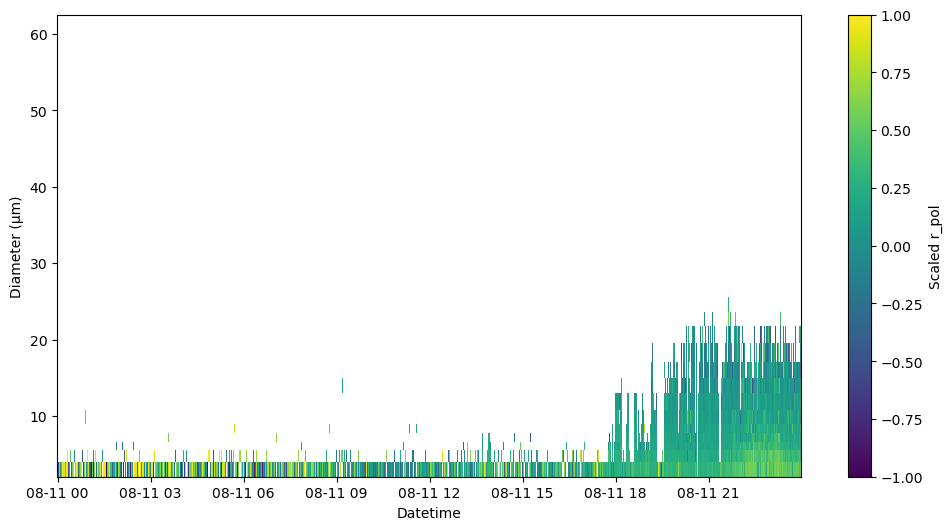

In [11]:
x = SP.index
y = SP.columns.astype(float)
z = SP.values

x, y = np.meshgrid(x, y)
plt.figure(figsize=(12, 6))
plt.pcolormesh(x, y, z.T, shading='auto', cmap='viridis')
plt.colorbar(label='Scaled r_pol')
plt.xlabel('Datetime')
plt.ylabel('Diameter (µm)')


#### f/b

In [12]:
# meta for sp needs to be binned diameters and datetime

FB = pbp.map_partitions(lambda df: df.loc[:, ['datetime', 'binned Diameter', 'scaled F/B']]
                        .groupby(['datetime', 'binned Diameter'], observed=False).
                        median().
                        reset_index().
                        pivot(index='datetime', columns='binned Diameter', values='scaled F/B'), meta = meta_sp)

# save polarization data
FB = FB.compute()
#FB.to_csv(f'/share/Lea/GFAS_FB_data/{day}.csv')

In [13]:


# if FB is already computed, read it in
'''FB = pd.read_csv(f'/share/Lea/GFAS_FB_data/{day}.csv', index_col=0, parse_dates=True)'''

"FB = pd.read_csv(f'/share/Lea/GFAS_FB_data/{day}.csv', index_col=0, parse_dates=True)"

Text(0, 0.5, 'Diameter (µm)')

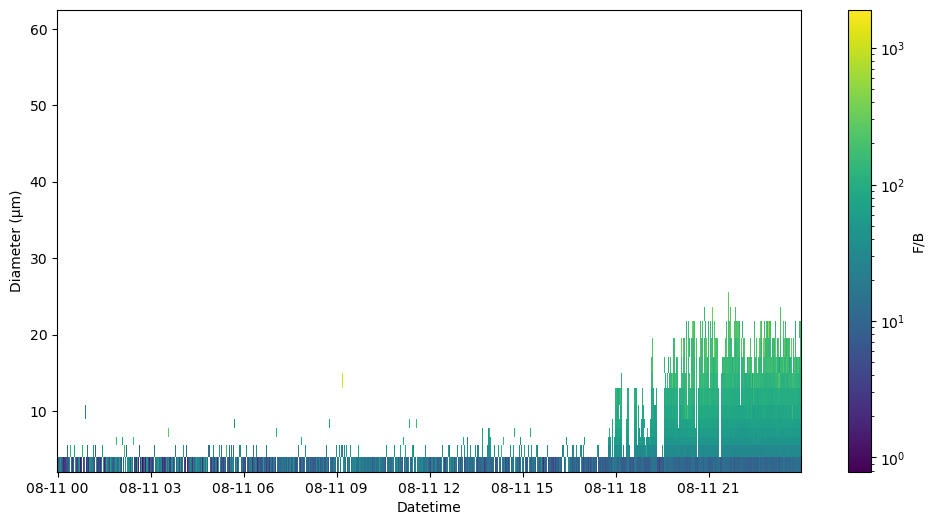

In [14]:
x = FB.index
y = FB.columns.astype(float)
z = FB.values
# find max value in z that is not inf or nan
z_max = np.nanmax(z[np.isfinite(z)])
x, y = np.meshgrid(x, y)
plt.figure(figsize=(12, 6))
plt.pcolormesh(x, y, z.T, shading='auto', cmap='viridis', norm=colors.LogNorm(vmin=np.nanmin(z[z>0]), vmax=z_max))
plt.colorbar(label='F/B')
plt.xlabel('Datetime')
plt.ylabel('Diameter (µm)')

In [15]:
del FB, SP

## make 1 Hz data

In [16]:
starttime = (pd.to_datetime(day) - pd.Timedelta(days=1)).strftime('%Y%m%d')

hz1 =  readGFAS101(path = path, starttime = starttime, endtime = day, timefmt = '%Y%m%d', filetype='GFAS_User_Data')

'''dlogDp = np.log10(diameter_bins[1:]) - np.log10(diameter_bins[:-1])
dlogDp[0] = np.log10(diameter_bins[1]) - np.log10(0.4499999880791)
dlogDp = pd.Series(dlogDp, index=diameter_bins[1:], dtype=float)'''

dDp = ((diameter_bins[1:])-diameter_bins[:-1]).astype(float)
dDp[0]= diameter_bins[1]-0.7
dDp = pd.Series(dDp, index=diameter_bins[1:], dtype=float)

#### calculate real measurement time 

In [17]:
# the timestamp for each detector runs on a "clock" that increases and one "tick" is a 70 ns time stamp. 
# to calculate the amount of time that has passed between the particles is therefore the difference between the timesteps multiplied by 70 ns (70*10**-9 s)
# we want to calculate the sum of all timesteps in each "computer time second" to calculate how long the GFAS sampled in each second to then calculate the true number concentration

In [18]:
times = pbp[['datetime', 'Sizer Timestamp']]
times['Sizer diff'] = times['Sizer Timestamp'].diff(periods = 1, axis = 0)
times['Sizer diff'] = times['Sizer diff']* 70*10**-9

times['Sizer diff'] = times['Sizer diff'].where(times['Sizer diff'] > 0, 0)
measurement_duration = times.groupby('datetime').sum()['Sizer diff']
measurement_duration = measurement_duration.compute()
measurement_duration =  measurement_duration.resample('1s').mean()

In [19]:
measurement_duration =  measurement_duration.resample('1s').mean()

#### continue with size distribution

In [20]:
# if meta_sp is not defined, define it as a dataframe with columns as diameter bins and index as datetime
if 'meta_sp' not in locals():
    meta_sp = pd.DataFrame(columns=diameter_bins[1:], index=pbp['datetime'].unique())

In [21]:
SD = pbp.map_partitions(lambda df: df.loc[:, ['datetime', 'binned Diameter', 'Diameter']]
                        .groupby(['datetime', 'binned Diameter'], observed=False)
                        .count()
                        .reset_index()
                        .pivot(index='datetime', columns='binned Diameter', values='Diameter'), meta = meta_sp
                        )
SD = SD.compute()
SD = SD.resample('1s').mean()
hz1 = hz1.resample('1s').mean()
idx = SD.index.intersection(hz1.index)

SD = SD.loc[idx].divide(hz1.loc[idx, 'Sample Volume Flow Rate (cm^3/s)'], axis = 0)
#SD.divide(measurement_duration, axis = 0)

SD.columns = SD.columns.astype(float)
dDp.index = dDp.index.astype(float) #dlogDp.index = dlogDp.index.astype(float)
SD = SD.divide(dDp, axis=1)

SD.replace(0, np.nan, inplace=True)
SD = SD.divide(measurement_duration, axis = 0)
#SD.to_csv(f'/share/Lea/GFAS_sizeDistribution_data/{day}.csv')
    

## Calculate N, LWC and Deff

In [22]:
hz1 = hz1.resample('1s').mean()
measurement_duration = measurement_duration.resample('1s').mean()

### $LWC$

In [23]:
pbp['droplet volume'] = (4/3)*np.pi*(pbp['Diameter']/2)**3
lwc = pbp.groupby('datetime')['droplet volume'].sum()


In [24]:
lwc = lwc.compute()
lwc = lwc.resample('1s').mean()
lwc = lwc.sort_index()

idx = lwc.index.intersection(hz1.index)

lwc = lwc.loc[idx].divide(hz1.loc[idx, 'Sample Volume Flow Rate (cm^3/s)'], axis = 0)
lwc = lwc.divide(measurement_duration, axis = 0)
lwc = lwc*10**-6

### $N$

In [25]:
N = pbp.groupby('datetime')['Diameter'].count()

N = N.compute()
N = N.sort_index()
N = N.resample('1s').mean()

idx = N.index.intersection(hz1.index)

N = N.divide(hz1.loc[idx, 'Sample Volume Flow Rate (cm^3/s)'], axis = 0)#.loc[idx]
N = N.divide(measurement_duration, axis = 0)


### $D_{eff}$

In [26]:
pbp['D3'] = pbp['Diameter']**3
pbp['D2'] = pbp['Diameter']**2
d = pbp[['D3', 'D2']].groupby(pbp['datetime']).sum()
D_eff = d['D3'] / d['D2']
D_eff = D_eff.compute()
D_eff = D_eff.resample('1s').mean().loc[idx]
D_eff = D_eff.sort_index()

### bring everything together into one dataframe

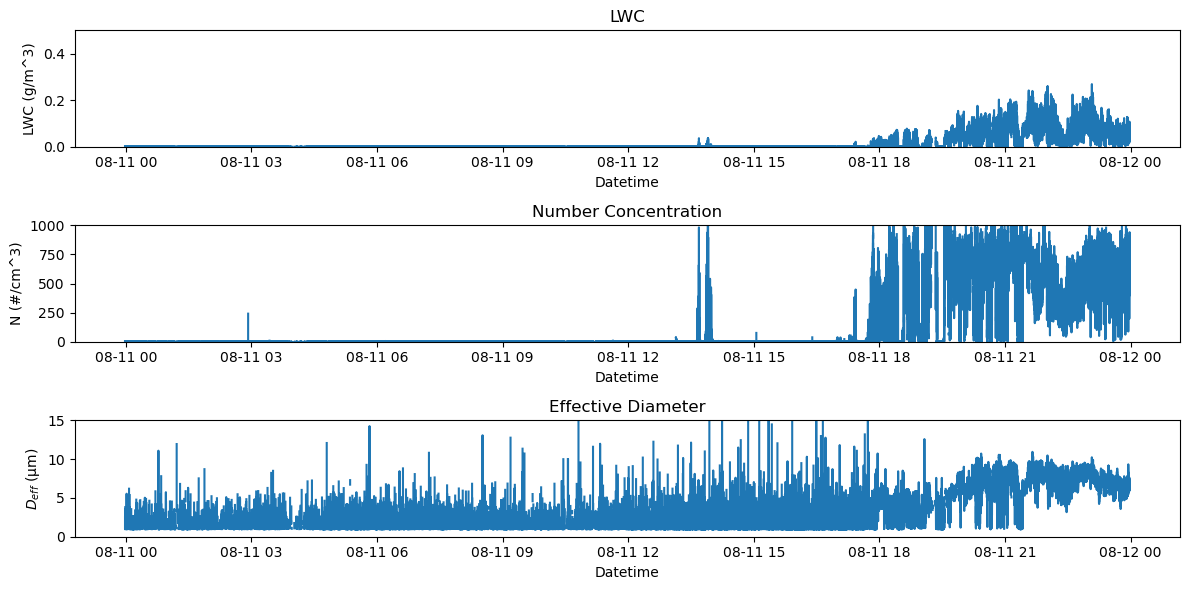

In [27]:
fig, ax = plt.subplots(3, figsize=(12, 6))
ax[0].plot(lwc.index, lwc.values)
ax[0].set(title='LWC', xlabel='Datetime', ylabel='LWC (g/m^3)', ylim = (0,0.5))
ax[1].plot(N.index, N.values)
ax[1].set(title='Number Concentration', xlabel='Datetime', ylabel='N (#/cm^3)', ylim = (0,1000))
ax[2].plot(D_eff.index, D_eff.values)
ax[2].set(title='Effective Diameter', xlabel='Datetime', ylabel='$D_{eff}$ (µm)', ylim = (0,15))
plt.tight_layout()
plt.show()

In [28]:
parameters = pd.concat([N, lwc, D_eff], axis=1, keys=['N', 'LWC', 'D_eff'])
#parameters.to_csv(f'/share/Lea/GFAS_sizeDistribution_data/parameters_{day}.csv')

## Loss corrections

In [29]:
SD = pd.read_csv(f'/share/Lea/GFAS_sizeDistribution_data/{day}.csv', index_col=0, parse_dates=True)
SD.columns = SD.columns.astype(float)

starttime = (pd.to_datetime(day) - pd.Timedelta(days=1)).strftime('%Y%m%d')
hz1 = readGFAS101(path = path, starttime = starttime, endtime = day, timefmt = '%Y%m%d', filetype='GFAS_User_Data')

parameters = pd.read_csv(f'/share/Lea/GFAS_sizeDistribution_data/parameters_{day}.csv', index_col=0, parse_dates=True)
parameters

,N,LWC,D_eff
datetime,,,
2024-08-10 23:58:52,1.184346,8.865452e-07,1.140049
2024-08-10 23:58:53,0.381186,3.118763e-06,2.500051
2024-08-10 23:58:54,NaN,NaN,NaN
2024-08-10 23:58:55,NaN,NaN,NaN
2024-08-10 23:58:56,NaN,NaN,NaN
...,...,...,...
2024-08-11 23:58:46,562.518369,3.732017e-02,6.225445
2024-08-11 23:58:47,NaN,NaN,6.505441
2024-08-11 23:58:48,754.989507,6.596233e-02,6.687266


In [30]:
hz1 = hz1.resample('1s').mean()
idx = SD.index.intersection(hz1.index)
SD = SD.loc[idx]
hz1 = hz1.loc[idx]

gfas = pd.concat([SD, hz1[['Sample Velocity (m/s)',
                           'GFAS Heading (deg)',
                           'Wind Speed (m/s)',
                           'Wind Direction (deg)',
                           ]]], axis=1)


In [31]:
def is_number(x):
    try:
        float(x)
        return True
    except:
        return False

numeric_name_cols = [c for c in gfas.columns if is_number(c)]

gfas.index.name = 'DateTime'
    # calculate overall efficiency for GFAS101
efficiency = lc.loss_calc_GFAS101(gfas, Wind = gfas, wind_GFAS=True,min_efficiency=0.01, return_sep=False)
    # create corrected GFAS101 data
corrected = gfas.resample('1min').mean()
x = lc.correction(gfas.loc[:,numeric_name_cols], efficiency, min_efficiency = 0.1, pandas = True)
x.columns = corrected.loc[:,numeric_name_cols].columns
corrected.loc[:,numeric_name_cols] = x.loc[:,numeric_name_cols]

    # calcualte N, Deff, LWC for corrected data; output = corrected parameters and corrected data for all bin sizes
correct_parameters = lc.correct_parameter(corrected.loc[:,numeric_name_cols] , min_val_series = parameters['N'], min_valED = 5)

    # create matrix for availability of efficiencies for each bin size (n_asp = aspiration efficiency, n_trm = transmission efficiency, n_tsp = transport efficiency)
        # calculate efficiencies by themselves
n_asp, n_trm, n_tsp = lc.loss_calc_GFAS101(gfas, wind_GFAS=True, Wind = gfas, return_sep=True)
        # availability of efficiencies
eff_flags = lc.efficiency_flags(n_asp, n_trm, n_tsp)

    # data array for quality assurance (0 = quality assured, 3 = not quality assured)
quality_assurance = lc.classify_quality(eff_flags)

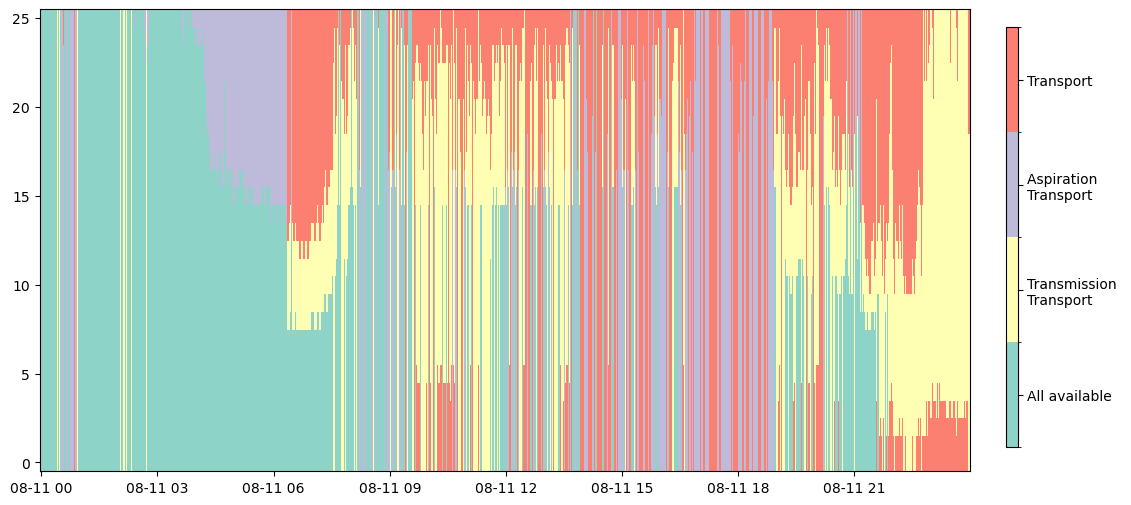

In [32]:
import matplotlib.colors as colors
# add flags for loss calculations
fl = eff_flags#.loc[start:end]
p = fl.DateTime.values
y = np.arange(0,fl.shape[1])
P,Y = np.meshgrid(p,y)
E = fl.astype(float).values.T
norm = colors.BoundaryNorm(boundaries= np.linspace(-0.5, int(fl.max()) + 0.5, int(fl.max()) + 2), ncolors= int(fl.max())+1)
fig, ax = plt.subplots(figsize=(12, 6))
d = ax.pcolor(P,Y,E, cmap='Set3', norm = norm) #vmin=10**(-2),vmax=10**3

dax = fig.add_axes([0.93,0.15,0.01,0.7]) # [(position:) left, bottom, (size:) width, height]
dbar = fig.colorbar(d, orientation='vertical', cax = dax )
lc.plot_flag_parameters(fl, dbar)

In [33]:
quality_assurance = quality_assurance.to_pandas()
eff_flags = eff_flags.to_pandas()

In [34]:
correct_parameters.to_csv(f'/share/Lea/GFAS_sizeDistribution_data/loss_corrected/data{day}.csv')
pd.DataFrame(eff_flags).to_csv(f'/share/Lea/GFAS_sizeDistribution_data/loss_corrected/efficiency_flags{day}.csv')
pd.DataFrame(quality_assurance).to_csv(f'/share/Lea/GFAS_sizeDistribution_data/loss_corrected/quality_assurance{day}.csv')

#### loss plots for paper

In [35]:
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 12,          # base size
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

In [36]:
eff_flag11 = pd.read_csv(f'/share/Lea/GFAS_sizeDistribution_data/loss_corrected/efficiency_flags20240811.csv', index_col = 'DateTime',parse_dates=True)
eff_flag12 = pd.read_csv(f'/share/Lea/GFAS_sizeDistribution_data/loss_corrected/efficiency_flags20240812.csv', index_col = 'DateTime',parse_dates=True)
eff_flag16 = pd.read_csv(f'/share/Lea/GFAS_sizeDistribution_data/loss_corrected/efficiency_flags20240816.csv', index_col = 'DateTime',parse_dates=True)

In [37]:
eff_flag11

,3e-06,4.9000000000000005e-06,6.2e-06,7e-06,8.5e-06,9.5e-06,1.2e-05,1.4e-05,1.6e-05,1.8e-05,...,3.35e-05,3.6e-05,3.75e-05,4e-05,4.2e-05,4.4e-05,4.8e-05,5e-05,5.5e-05,6e-05
DateTime,,,,,,,,,,,,,,,,,,,,,
2024-08-10 23:58:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-08-10 23:59:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-08-11 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-08-11 00:01:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-08-11 00:02:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-11 23:54:00,3.0,3.0,3.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2024-08-11 23:55:00,3.0,3.0,3.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2024-08-11 23:56:00,3.0,3.0,3.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [38]:
start = pd.to_datetime('2024-08-11 15:00') # '2024-08-11 15:00'
end =  pd.to_datetime('2024-08-12 06:00') #'2024-08-12 06:00'

eff_cloud = pd.concat([eff_flag11, eff_flag12])
eff_cloud.index = pd.DatetimeIndex(eff_cloud.index)
eff_cloud = eff_cloud.loc[start:end]
    

In [39]:
start = pd.to_datetime('2024-08-16 00:00') # '2024-08-11 15:00'
end =  pd.to_datetime('2024-08-16 18:00') #'2024-08-12 06:00'
eff_dust = eff_flag16.loc[start:end]

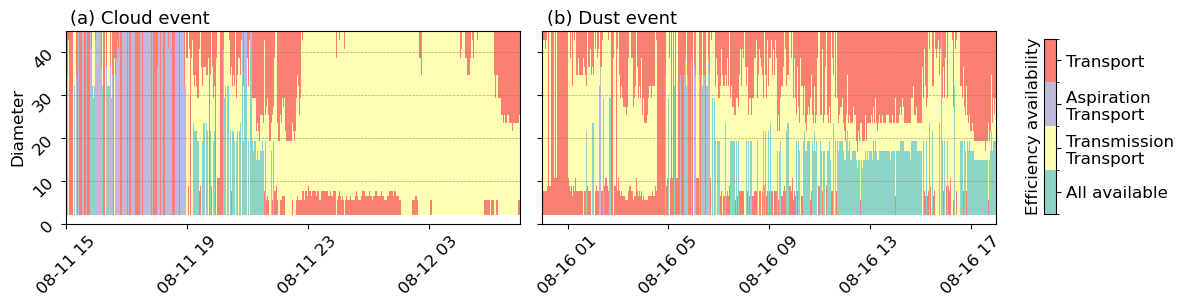

In [40]:
import matplotlib.colors as colors
import loss_Calc_functions_GFAS101 as lc
importlib.reload(lc)

# add flags for loss calculations
fl = eff_cloud
p = fl.index.values
y = fl.columns.astype(float) *10**6
P,Y = np.meshgrid(p,y)
E = fl.astype(float).values.T

fl2 = eff_dust
a = fl2.index.values
b = fl2.columns.astype(float) *10**6
A,B = np.meshgrid(a,b)
C = fl2.astype(float).values.T

norm_c = colors.BoundaryNorm(boundaries= np.linspace(-0.5, int(fl.values.max()) + 0.5, int(fl.values.max()) + 2), ncolors= int(fl.values.max())+1)
norm_d = colors.BoundaryNorm(boundaries= np.linspace(-0.5, int(fl2.values.max()) + 0.5, int(fl2.values.max()) + 2), ncolors= int(fl2.values.max())+1)


fig, ax = plt.subplots(1, 2, figsize=(12,2.5), sharey = True)
c = ax[0].pcolor(P,Y,E, cmap='Set3', norm = norm_c) #vmin=10**(-2),vmax=10**3
d = ax[1].pcolor(A,B,C, cmap='Set3', norm = norm_d)
ax[0].set(ylim = (0,45), ylabel = 'Diameter')

dax = fig.add_axes([0.94,0.15,0.01,0.7]) # [(position:) left, bottom, (size:) width, height]
dbar = fig.colorbar(c, orientation='vertical', cax = dax, label ='Efficiency availability' )

for axs in ax:       
    axs.tick_params(axis='both',which='major', rotation = 45)
    axs.xaxis.set_major_locator(mdates.HourLocator(interval=4))
    myFmt = mdates.DateFormatter('%m-%d %H')
    axs.xaxis.set_major_formatter(myFmt)
    axs.grid(which = 'major', axis = 'y', color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
lc.plot_flag_parameters(fl.values, dbar)

dbar.set_label('Efficiency availability', labelpad=-110,  fontsize = 12)#y=1.15, rotation=270,

ax[0].text(0.01,1.11, '(a) Cloud event', transform=ax[0].transAxes, fontsize=13, va='top', ha='left', 
               )
ax[1].text(0.01,1.11, '(b) Dust event', transform=ax[1].transAxes, fontsize=13, va='top', ha='left', 
               )

plt.subplots_adjust(wspace = 0.05)
fig.savefig('/home/leha7253/Paper1_plots/efficiencies.png', bbox_inches='tight', dpi = 300)

## test sizes etc.

In [41]:
SP = pd.read_csv(f'/share/Lea/GFAS_pol_data/{day}.csv', index_col=0, parse_dates=True)
FB = pd.read_csv(f'/share/Lea/GFAS_FB_data/{day}.csv', index_col=0, parse_dates=True)
SD = pd.read_csv(f'/share/Lea/GFAS_sizeDistribution_data/{day}.csv', index_col=0, parse_dates=True)

In [42]:

sd16 = pd.read_csv(f'/share/Lea/GFAS_sizeDistribution_data/{20240816}.csv', index_col=0, parse_dates=True)
params16 = pd.read_csv(f'/share/Lea/GFAS_sizeDistribution_data/parameters_{20240816}.csv', index_col=0, parse_dates=True)
GFAS = pd.concat([sd16, params16], axis=1)
del sd16,  params16,

GFAS = GFAS.shift(freq=pd.Timedelta(seconds=-60))
gfas = GFAS.resample('1min').median()
gg = gfas.resample('5min').mean()

In [43]:
SP.index = pd.DatetimeIndex(SP.index)
FB.index = pd.DatetimeIndex(FB.index)
SD.index = pd.DatetimeIndex(SD.index)

# build a meshgrid for plotting polarization
x = pd.to_datetime(SP.index).to_numpy(dtype="datetime64[ns]")
y = SP.columns.to_numpy(dtype=float)
Z = SP.to_numpy(dtype=float).T
X,Y = np.meshgrid(x,y)

a = pd.to_datetime(FB.index).to_numpy(dtype="datetime64[ns]")
b = FB.columns.to_numpy(dtype=float)
C = FB.to_numpy(dtype=float).T
A,B = np.meshgrid(a,b)

d = pd.to_datetime(SD.index).to_numpy(dtype="datetime64[ns]")
e = SD.columns.to_numpy(dtype=float)
F = SD.to_numpy(dtype=float).T
D,E = np.meshgrid(d,e)

def is_number(x):
    try:
        float(x)
        return True
    except:
        return False

numeric_cols_gfas = [c for c in GFAS.columns if is_number(c)]

g = GFAS.astype('float').astype(float).index
h = (GFAS.loc[:,numeric_cols_gfas].columns.astype('float').values)
I = (GFAS.loc[:,numeric_cols_gfas].astype('float').values ).T

G,H = np.meshgrid(g,h)


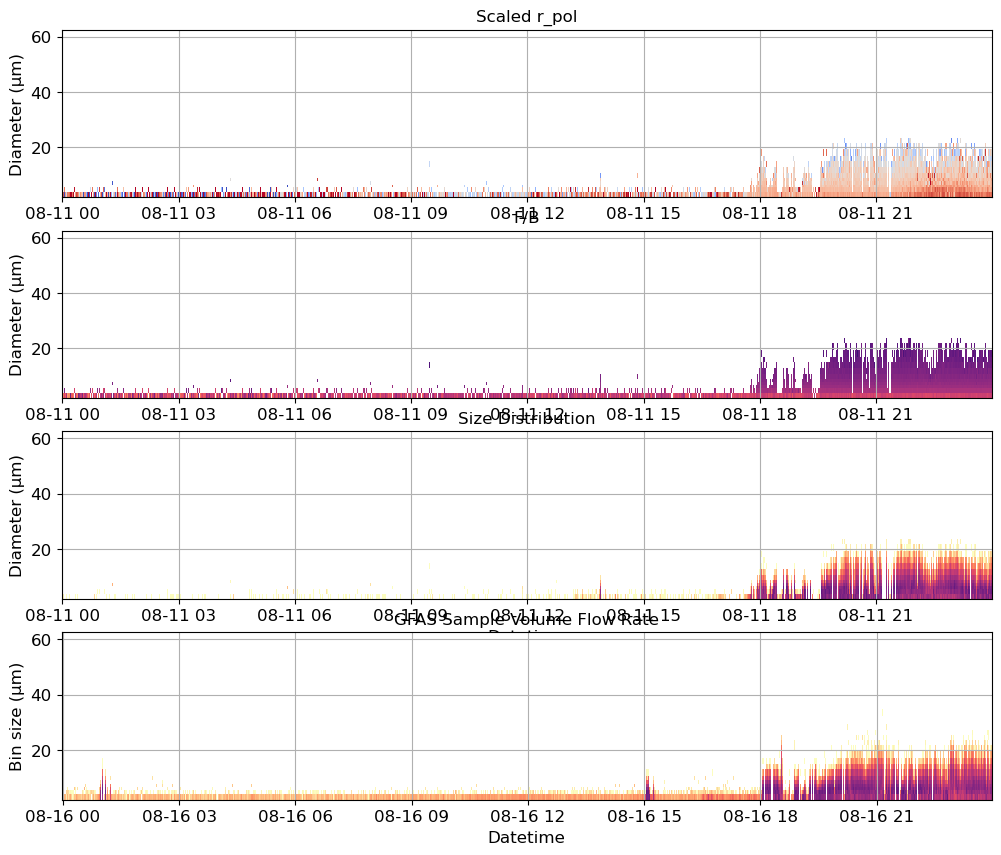

In [44]:
vmin = 10**(-1)
vmax = 5000

fig, ax = plt.subplots(4, figsize = (12,10))
ax[0].pcolormesh(X,Y,Z,cmap ='coolwarm', vmin = -0.75, vmax = 0.75, shading = 'auto') 
ax[1].pcolormesh(A,B,C,cmap ='magma_r',  shading = 'auto',norm = colors.LogNorm(vmin=vmin,vmax=vmax)) 
ax[2].pcolormesh(D,E,F,cmap ='magma_r',  shading = 'auto',norm = colors.LogNorm(vmin=vmin,vmax=vmax)) 
ax[3].pcolormesh(G,H,I,cmap ='magma_r',  shading = 'auto',norm = colors.LogNorm(vmin=vmin,vmax=vmax))
ax[0].set(title = 'Scaled r_pol', ylabel = 'Diameter (µm)')
ax[1].set(title = 'F/B', ylabel = 'Diameter (µm)')
ax[2].set(title = 'Size Distribution', ylabel = 'Diameter (µm)', xlabel = 'Datetime')
ax[3].set(title = 'GFAS Sample Volume Flow Rate', ylabel = 'Bin size (µm)', xlabel = 'Datetime')
for axs in ax:
    axs.grid(which = 'major')
